**<div style='text-align: center; font-size: 48px'><u>Experiment 4 : Data Analytics I</u></div>**

### <div align="center"> Name : Shravan Santosh Shidruk , PRN : 72311412K </div>

### <div align="center"> Dataset Used : [Boston Housing Dataset](https://www.kaggle.com/c/boston-housing) </div>

---

### <div align="center"> Dataset Description </div>

This experiment uses the Boston Housing dataset obtained from Kaggle.

The dataset contains information about various houses in Boston, including multiple features that influence housing prices such as crime rate, number of rooms, property tax rate, and accessibility to highways.

Source: https://www.kaggle.com/c/boston-housing  

This dataset is suitable for data analytics as it contains numerical features that can be used to build a Linear Regression model for predicting house prices.

---

<b> Variable Descriptions: </b>

* CRIM: Per capita crime rate by town (Numeric)  
* ZN: Proportion of residential land zoned for large lots (Numeric)  
* INDUS: Proportion of non-retail business acres per town (Numeric)  
* CHAS: Charles River dummy variable (Categorical/Numeric)  
* NOX: Nitric oxide concentration (Numeric)  
* RM: Average number of rooms per dwelling (Numeric)  
* AGE: Proportion of owner-occupied units built prior to 1940 (Numeric)  
* DIS: Weighted distances to employment centers (Numeric)  
* RAD: Index of accessibility to radial highways (Numeric)  
* TAX: Property tax rate (Numeric)  
* PTRATIO: Pupil-teacher ratio (Numeric)  
* B: Proportion related to Black population (Numeric)  
* LSTAT: Percentage of lower status population (Numeric)  
* MEDV: Median value of owner-occupied homes (Target Variable)  

---

In [35]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

In [36]:
df = pd.read_csv('HousingData.csv')

In [37]:
df.head()

,CRIM,ZN,INDUS,CHAS,NOX,RM,AGE,DIS,RAD,TAX,PTRATIO,B,LSTAT,MEDV
0,0.00632,18.0,2.31,0.0,0.538,6.575,65.2,4.0900,1,296,15.3,396.90,4.98,24.0
1,0.02731,0.0,7.07,0.0,0.469,6.421,78.9,4.9671,2,242,17.8,396.90,9.14,21.6
2,0.02729,0.0,7.07,0.0,0.469,7.185,61.1,4.9671,2,242,17.8,392.83,4.03,34.7
3,0.03237,0.0,2.18,0.0,0.458,6.998,45.8,6.0622,3,222,18.7,394.63,2.94,33.4
4,0.06905,0.0,2.18,0.0,0.458,7.147,54.2,6.0622,3,222,18.7,396.90,NaN,36.2


In [38]:
df.shape

(506, 14)

In [39]:
print(df.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 506 entries, 0 to 505
Data columns (total 14 columns):
 #   Column   Non-Null Count  Dtype  
---  ------   --------------  -----  
 0   CRIM     486 non-null    float64
 1   ZN       486 non-null    float64
 2   INDUS    486 non-null    float64
 3   CHAS     486 non-null    float64
 4   NOX      506 non-null    float64
 5   RM       506 non-null    float64
 6   AGE      486 non-null    float64
 7   DIS      506 non-null    float64
 8   RAD      506 non-null    int64  
 9   TAX      506 non-null    int64  
 10  PTRATIO  506 non-null    float64
 11  B        506 non-null    float64
 12  LSTAT    486 non-null    float64
 13  MEDV     506 non-null    float64
dtypes: float64(12), int64(2)
memory usage: 55.5 KB
None


In [40]:
df.isnull().sum()

CRIM       20
ZN         20
INDUS      20
CHAS       20
NOX         0
RM          0
AGE        20
DIS         0
RAD         0
TAX         0
PTRATIO     0
B           0
LSTAT      20
MEDV        0
dtype: int64

#### Handling Missing Values - Replacing missing values with mean

In [41]:
for col in ['CRIM','ZN','INDUS','CHAS','AGE','LSTAT']:
    df[col] = df[col].fillna(df[col].mean())

In [42]:
df.isnull().sum()

CRIM       0
ZN         0
INDUS      0
CHAS       0
NOX        0
RM         0
AGE        0
DIS        0
RAD        0
TAX        0
PTRATIO    0
B          0
LSTAT      0
MEDV       0
dtype: int64

In [43]:
df.describe()

,CRIM,ZN,INDUS,CHAS,NOX,RM,AGE,DIS,RAD,TAX,PTRATIO,B,LSTAT,MEDV
count,506.000000,506.000000,506.000000,506.000000,506.000000,506.000000,506.000000,506.000000,506.000000,506.000000,506.000000,506.000000,506.000000,506.000000
mean,3.611874,11.211934,11.083992,0.069959,0.554695,6.284634,68.518519,3.795043,9.549407,408.237154,18.455534,356.674032,12.715432,22.532806
std,8.545770,22.921051,6.699165,0.250233,0.115878,0.702617,27.439466,2.105710,8.707259,168.537116,2.164946,91.294864,7.012739,9.197104
min,0.006320,0.000000,0.460000,0.000000,0.385000,3.561000,2.900000,1.129600,1.000000,187.000000,12.600000,0.320000,1.730000,5.000000
25%,0.083235,0.000000,5.190000,0.000000,0.449000,5.885500,45.925000,2.100175,4.000000,279.000000,17.400000,375.377500,7.230000,17.025000
50%,0.290250,0.000000,9.900000,0.000000,0.538000,6.208500,74.450000,3.207450,5.000000,330.000000,19.050000,391.440000,11.995000,21.200000
75%,3.611874,11.211934,18.100000,0.000000,0.624000,6.623500,93.575000,5.188425,24.000000,666.000000,20.200000,396.225000,16.570000,25.000000
max,88.976200,100.000000,27.740000,1.000000,0.871000,8.780000,100.000000,12.126500,24.000000,711.000000,22.000000,396.900000,37.970000,50.000000


### Correlation Heatmap

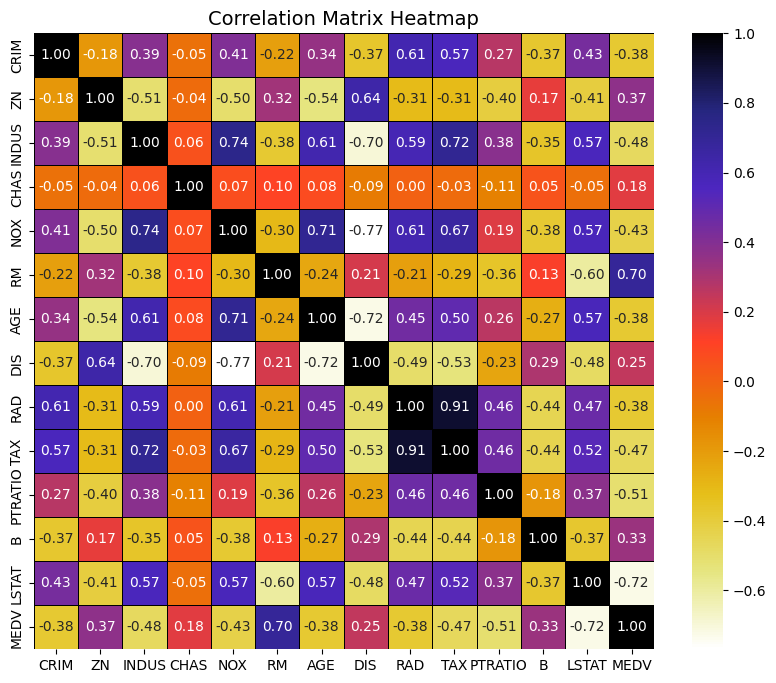

In [44]:
plt.figure(figsize=(10,8))  # makes it readable

sns.heatmap(
    df.corr(), 
    annot=True,          # shows correlation values
    fmt=".2f",           # show 2 decimal places
    cmap=plt.cm.CMRmap_r,# best colour theme for heatmap plot
    linewidths=0.5,      # lines between boxes
    linecolor='black'
)

plt.title("Correlation Matrix Heatmap", fontsize=14)
plt.show()

### Split Dataset into Independent and Dependent Features

In [45]:
X = df.drop('MEDV', axis=1)   # Features (independent variables)
y = df['MEDV']                # Target (dependent variable)

### Splitting Data into Train-Test Split

In [46]:
from sklearn.model_selection import train_test_split
from sklearn.impute import SimpleImputer

X = df.drop('MEDV', axis=1)
y = df['MEDV']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

imputer = SimpleImputer(strategy='mean')
X_train = imputer.fit_transform(X_train)
X_test = imputer.transform(X_test)

In [47]:
X_train

array([[1.50234000e+01, 0.00000000e+00, 1.81000000e+01, ...,
        2.02000000e+01, 3.49480000e+02, 2.49100000e+01],
       [6.27390000e-01, 0.00000000e+00, 8.14000000e+00, ...,
        2.10000000e+01, 3.95620000e+02, 8.47000000e+00],
       [3.46600000e-02, 1.12119342e+01, 6.06000000e+00, ...,
        1.69000000e+01, 3.62250000e+02, 7.83000000e+00],
       ...,
       [1.50100000e-02, 8.00000000e+01, 2.01000000e+00, ...,
        1.70000000e+01, 3.90940000e+02, 5.99000000e+00],
       [1.11604000e+01, 0.00000000e+00, 1.81000000e+01, ...,
        2.02000000e+01, 1.09850000e+02, 2.32700000e+01],
       [2.28760000e-01, 0.00000000e+00, 8.56000000e+00, ...,
        2.09000000e+01, 7.08000000e+01, 1.06300000e+01]], shape=(404, 13))

In [48]:
X_test

array([[9.17800000e-02, 0.00000000e+00, 1.10839918e+01, ...,
        1.66000000e+01, 3.95500000e+02, 9.04000000e+00],
       [5.64400000e-02, 4.00000000e+01, 6.41000000e+00, ...,
        1.76000000e+01, 3.96900000e+02, 3.53000000e+00],
       [1.05740000e-01, 0.00000000e+00, 2.77400000e+01, ...,
        2.01000000e+01, 3.90110000e+02, 1.80700000e+01],
       ...,
       [1.40507000e+01, 0.00000000e+00, 1.81000000e+01, ...,
        2.02000000e+01, 3.50500000e+01, 2.12200000e+01],
       [5.18800000e-02, 0.00000000e+00, 4.49000000e+00, ...,
        1.85000000e+01, 3.95990000e+02, 1.28600000e+01],
       [9.51200000e-02, 0.00000000e+00, 1.28300000e+01, ...,
        1.87000000e+01, 3.83230000e+02, 8.94000000e+00]], shape=(102, 13))

In [49]:
y_train

477    12.0
15     19.9
332    19.4
423    13.4
19     18.2
       ... 
106    19.5
270    21.1
348    24.5
435    13.4
102    18.6
Name: MEDV, Length: 404, dtype: float64

In [50]:
y_test

173    23.6
274    32.4
491    13.6
72     22.8
452    16.1
       ... 
412    17.9
436     9.6
411    17.2
86     22.5
75     21.4
Name: MEDV, Length: 102, dtype: float64

## Train Linear Regression Model

In [51]:
from sklearn.linear_model import LinearRegression
model = LinearRegression()
model.fit(X_train,y_train)

,fit_intercept,True
,copy_X,True
,tol,1e-06
,n_jobs,None
,positive,False


## Evaluating Model Accuracy

In [53]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

# Predictions
y_pred = model.predict(X_test)

# Metrics
mse = mean_squared_error(y_test, y_pred)
mae = mean_absolute_error(y_test, y_pred)
rmse = np.sqrt(mse)
r2 = r2_score(y_test, y_pred)

# Adjusted R2
n = len(y_test)
p = X_test.shape[1]

adj_r2 = 1 - (1 - r2) * (n - 1) / (n - p - 1)

# Print results
print(f"MSE: {mse}")
print(f"MAE: {mae}")
print(f"RMSE: {rmse}")
print(f"R2 Score: {r2}")
print(f"Adjusted R2 Score: {adj_r2}")

MSE: 25.017672023842596
MAE: 3.149923357345766
RMSE: 5.001766890194164
R2 Score: 0.6588520195508154
Adjusted R2 Score: 0.6084551588026403


---

### <div align="center"> Conclusion </div>

- In this experiment, a Linear Regression model was developed to predict housing prices using the Boston Housing dataset. The dataset consists of various numerical features that influence house prices, and the target variable MEDV represents the median value of owner-occupied homes.

- The model was trained and evaluated using performance metrics such as Mean Squared Error (MSE), Mean Absolute Error (MAE), Root Mean Squared Error (RMSE), R² Score, and Adjusted R² Score. The obtained R² score of approximately 0.66 indicates that the model explains around 66% of the variance in housing prices. The RMSE value of approximately 5 suggests a moderate prediction error.

- Overall, the Linear Regression model provides a reasonably good fit for the dataset. However, the performance can be further improved by applying techniques such as feature engineering, scaling, or using advanced regression models.

---